<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Define the column names
column_names = ['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality', 'Load','Machine Type','Failure Type','Component Type']

# Generate random data for each column
num_rows = 100
data = {
    'Temperature': np.random.uniform(20, 100, num_rows),  # Temperature between 20 and 100
    'Vibration': np.random.uniform(0, 1, num_rows),  # Vibration between 0 and 1
    'Pressure': np.random.uniform(1, 10, num_rows),  # Pressure between 1 and 10
    'Humidity': np.random.uniform(30, 80, num_rows),  # Humidity between 30 and 80
    'RPM': np.random.uniform(1000, 5000, num_rows),  # RPM between 1000 and 5000
    'Voltage': np.random.uniform(110, 240, num_rows),  # Voltage between 110 and 240
    'Current': np.random.uniform(1, 10, num_rows),  # Current between 1 and 10
    'Sound_Level': np.random.uniform(60, 100, num_rows),  # Sound level between 60 and 100
    'Oil_Quality': np.random.uniform(0, 1, num_rows),  # Oil quality between 0 and 1
    'Load': np.random.uniform(0, 100, num_rows),  # Load between 0 and 100
    'Machine Type': np.random.choice(['Pump', 'Motor', 'Compressor', 'Turbine'], num_rows),  # Randomly assigns one of the four machine types to each row
    'Failure Type': np.random.choice(['Overheating', 'Vibration, Wear', 'Electrical', 'No Failure'], num_rows),  # Randomly assigns one of the four failure types to each row
    'Component Type': np.random.choice(['Bearing', 'Gear', 'Seal', 'Fan Blade'], num_rows)  # Randomly assigns one of the four component types to each row
}

# Combine columns to the data to create the dataset
pred = pd.DataFrame(data, columns=column_names)



In [3]:
pred.head()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
0,32.554275,0.968011,5.123102,69.198149,2301.961648,156.694714,6.648168,62.498597,0.964134,65.016917,Pump,Overheating,Fan Blade
1,42.838575,0.791563,8.183782,33.235683,4685.341815,132.740666,3.967657,83.842024,0.523756,8.115943,Motor,"Vibration, Wear",Seal
2,78.465328,0.768979,1.195937,77.716283,1675.661590,222.973618,3.601804,83.507729,0.287514,79.776381,Compressor,"Vibration, Wear",Fan Blade
3,48.975509,0.338871,3.311100,35.574022,3359.528404,128.358441,2.584530,75.994811,0.325390,59.233146,Motor,"Vibration, Wear",Seal
4,54.627706,0.234480,3.283216,65.613088,1570.882101,128.381627,7.188689,78.130359,0.141394,63.143753,Compressor,"Vibration, Wear",Fan Blade


In [4]:
pred.tail()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
95,74.358026,0.804631,6.868586,56.662376,3334.024300,182.568068,5.092233,75.094359,0.566412,76.893574,Motor,Electrical,Gear
96,28.977835,0.668934,7.105838,47.873403,1461.726609,197.038677,7.599075,83.565876,0.378533,91.184101,Pump,No Failure,Gear
97,83.141645,0.114341,3.159185,32.605457,2536.800930,133.764451,4.840351,75.445814,0.508839,50.225394,Turbine,"Vibration, Wear",Fan Blade
98,40.445827,0.318588,4.323657,44.121745,4650.305772,192.211590,4.213495,89.205736,0.220386,21.964344,Compressor,"Vibration, Wear",Seal
99,61.438171,0.326705,2.720799,74.589082,2015.203604,140.712449,5.582939,73.184678,0.499203,22.301489,Pump,"Vibration, Wear",Seal


# **Exploratory Data Analysis**

In [5]:
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     100 non-null    float64
 1   Vibration       100 non-null    float64
 2   Pressure        100 non-null    float64
 3   Humidity        100 non-null    float64
 4   RPM             100 non-null    float64
 5   Voltage         100 non-null    float64
 6   Current         100 non-null    float64
 7   Sound_Level     100 non-null    float64
 8   Oil_Quality     100 non-null    float64
 9   Load            100 non-null    float64
 10  Machine Type    100 non-null    object 
 11  Failure Type    100 non-null    object 
 12  Component Type  100 non-null    object 
dtypes: float64(10), object(3)
memory usage: 10.3+ KB


In [6]:
pred.describe()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,62.677537,0.505038,5.017020,55.655496,3039.295658,175.907699,5.750368,77.644030,0.465546,47.728602
std,22.600448,0.292487,2.407347,14.380946,1153.716512,36.758351,2.375209,11.443347,0.290823,29.571093
min,20.791584,0.005983,1.042869,30.422041,1003.080067,111.924153,1.023585,60.096190,0.012099,1.587999
25%,41.810831,0.241527,3.144534,42.687558,2004.052664,139.562302,3.798499,69.616104,0.223625,21.912764
50%,65.118517,0.437866,4.698675,56.788300,3016.642473,181.555441,6.192156,75.678482,0.440495,49.027463
75%,78.514861,0.765051,6.927899,67.186975,3985.814601,205.900383,7.499897,85.661821,0.713499,73.334911
max,99.863946,0.985151,9.947231,79.955381,4985.555890,238.584850,9.885007,99.087261,0.996438,98.612100


             Temperature  Vibration  Pressure  Humidity       RPM   Voltage  \
Temperature     1.000000  -0.070347 -0.032316  0.056885 -0.040682  0.072820   
Vibration      -0.070347   1.000000  0.085913 -0.008621 -0.086771  0.138896   
Pressure       -0.032316   0.085913  1.000000 -0.023877  0.174223  0.079541   
Humidity        0.056885  -0.008621 -0.023877  1.000000 -0.119355  0.148244   
RPM            -0.040682  -0.086771  0.174223 -0.119355  1.000000 -0.100994   
Voltage         0.072820   0.138896  0.079541  0.148244 -0.100994  1.000000   
Current         0.139038  -0.012793 -0.076995  0.076702  0.031386 -0.105647   
Sound_Level    -0.255113  -0.046720  0.126593 -0.086164  0.002432 -0.215547   
Oil_Quality    -0.017972  -0.086211  0.078262  0.017948 -0.238289 -0.070205   
Load            0.042961   0.103830  0.039882  0.059540 -0.068485  0.056704   

              Current  Sound_Level  Oil_Quality      Load  
Temperature  0.139038    -0.255113    -0.017972  0.042961  
Vibration 

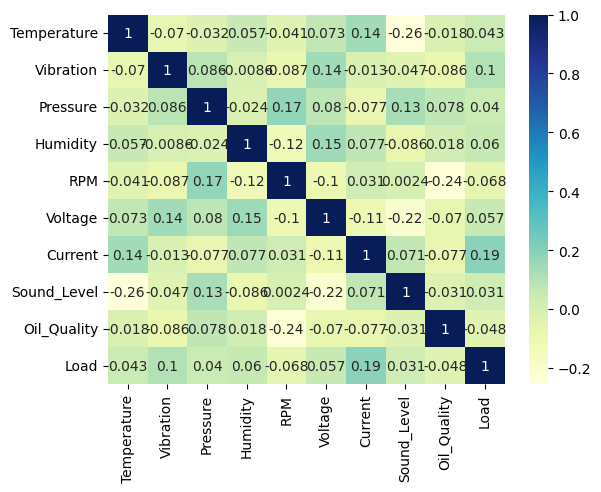

In [7]:
co_mtx = pred.corr(numeric_only=True)

print(co_mtx)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

# **Random Forest**

In [8]:
for col in pred:
  if pred[col].dtype == 'O':
    codes, _ = pd.factorize(pred[col])
    pred[col] = codes

In [9]:
X = pred[['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality','Load',
          'Failure Type','Component Type','Machine Type']]
y = pred['Component Type']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9
Recall: 0.9
Precision: 0.925
F1 Score: 0.8988095238095237
classification_report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.75      1.00      0.86         6
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         1

    accuracy                           0.90        20
   macro avg       0.94      0.93      0.92        20
weighted avg       0.93      0.90      0.90        20



In [12]:
model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Mean Absolute Error:', np.mean(np.abs(y_test - y_pred)))

Mean Absolute Error: 0.0
